In [28]:
%pip install anthropic python-dotenv

You should consider upgrading via the '/Users/techment/projects/claude-tutorial/building-with-claudee-api/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [29]:
from dotenv import load_dotenv
load_dotenv()

from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-5"


In [30]:
message = client.messages.create(
    model="claude-sonnet-4-6", 
    max_tokens=1000,
    messages=[
        {
            "role": "user",
            "content": "What is quantum computing? Answer in one sentence"
        }
    ]
)


Print  the output here

In [31]:

message.content[0].text

'Quantum computing is a type of computation that uses quantum mechanical phenomena, such as superposition and entanglement, to process information in ways that can solve certain complex problems much faster than classical computers.'

Create a Builder Helper Functions

In [32]:
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

def chat(messages, system=None, temperature=0.0, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature         
    }

    if system:
        params["system"] = system
        
    if stop_sequences:
        params["stop_sequences"] = stop_sequences

    message = client.messages.create(**params)
    return message.content[0].text

Putting It All Together 

In [33]:
# Start with an empty message list
messages = []

# Add the initial user question
add_user_message(messages, "Define quantum computing in one sentence")

# Get Claude's response
answer = chat(messages)

# Add Claude's response to the conversation history
add_assistant_message(messages, answer)

# Add a follow-up question
add_user_message(messages, "Write another sentence")

# Get the follow-up response with full context
final_answer = chat(messages)
print(final_answer)

Quantum computers use quantum bits (qubits) that can exist in multiple states simultaneously, unlike classical bits which can only be either 0 or 1.


#### 1. Chat Bot Exercise 🧠

Make a chat bot using the three helper functions we just put together.

1. Prompt the user to enter some input using the built-in "input" function
2. Add it to a list of messages
3. Call the API
4. Add generated text to the list of messages
5. Print the generated text
6. Repeat from

In [34]:
messages  =[]
while True:
  user_input = input(">")
  print(">",user_input)

  add_user_message(messages,user_input)
  answer  = chat(messages)
  add_assistant_message(messages,answer)

  print("---")
  print(answer)
  print("---")
  

> 


BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0: user messages must have non-empty content'}, 'request_id': 'req_011CbxdLzbe8EW3Ldqvgiyrd'}

#### 2. Chat Bot Exercise 🧠


Math Tutor Specialist
• Responses should:
• Initially, only give the student hints
• Patiently walk the student through a solution
• Show solutions for similar problems
• Responses should not:
• Immediately give a direct answer
• Tell the student to use a calculator

### What is System prompt 

System prompts provide claude guidance on how to respond. Claude will try the same way someone in the  specified role would respond. 


In [ ]:
messages = []
add_user_message(messages,"How do I solve 5x+3=2 for x?")

system = """
    You are a patient math tutor. Do not directly answer a student's questions. 
    Guide them to a solution step by step
     """


answer = chat(messages,system)
answer

#### 3.Exercise 🧠

##### Write a Python function that checks a string for duplicate characters. 


In [ ]:
from itertools import chain
messages =[]
add_user_message(messages,"Write a Python function that checks a string for duplicate characters. ")
answer  = chat(messages, system="You are a Python engineer who writes very concise code")
answer

Temperture 

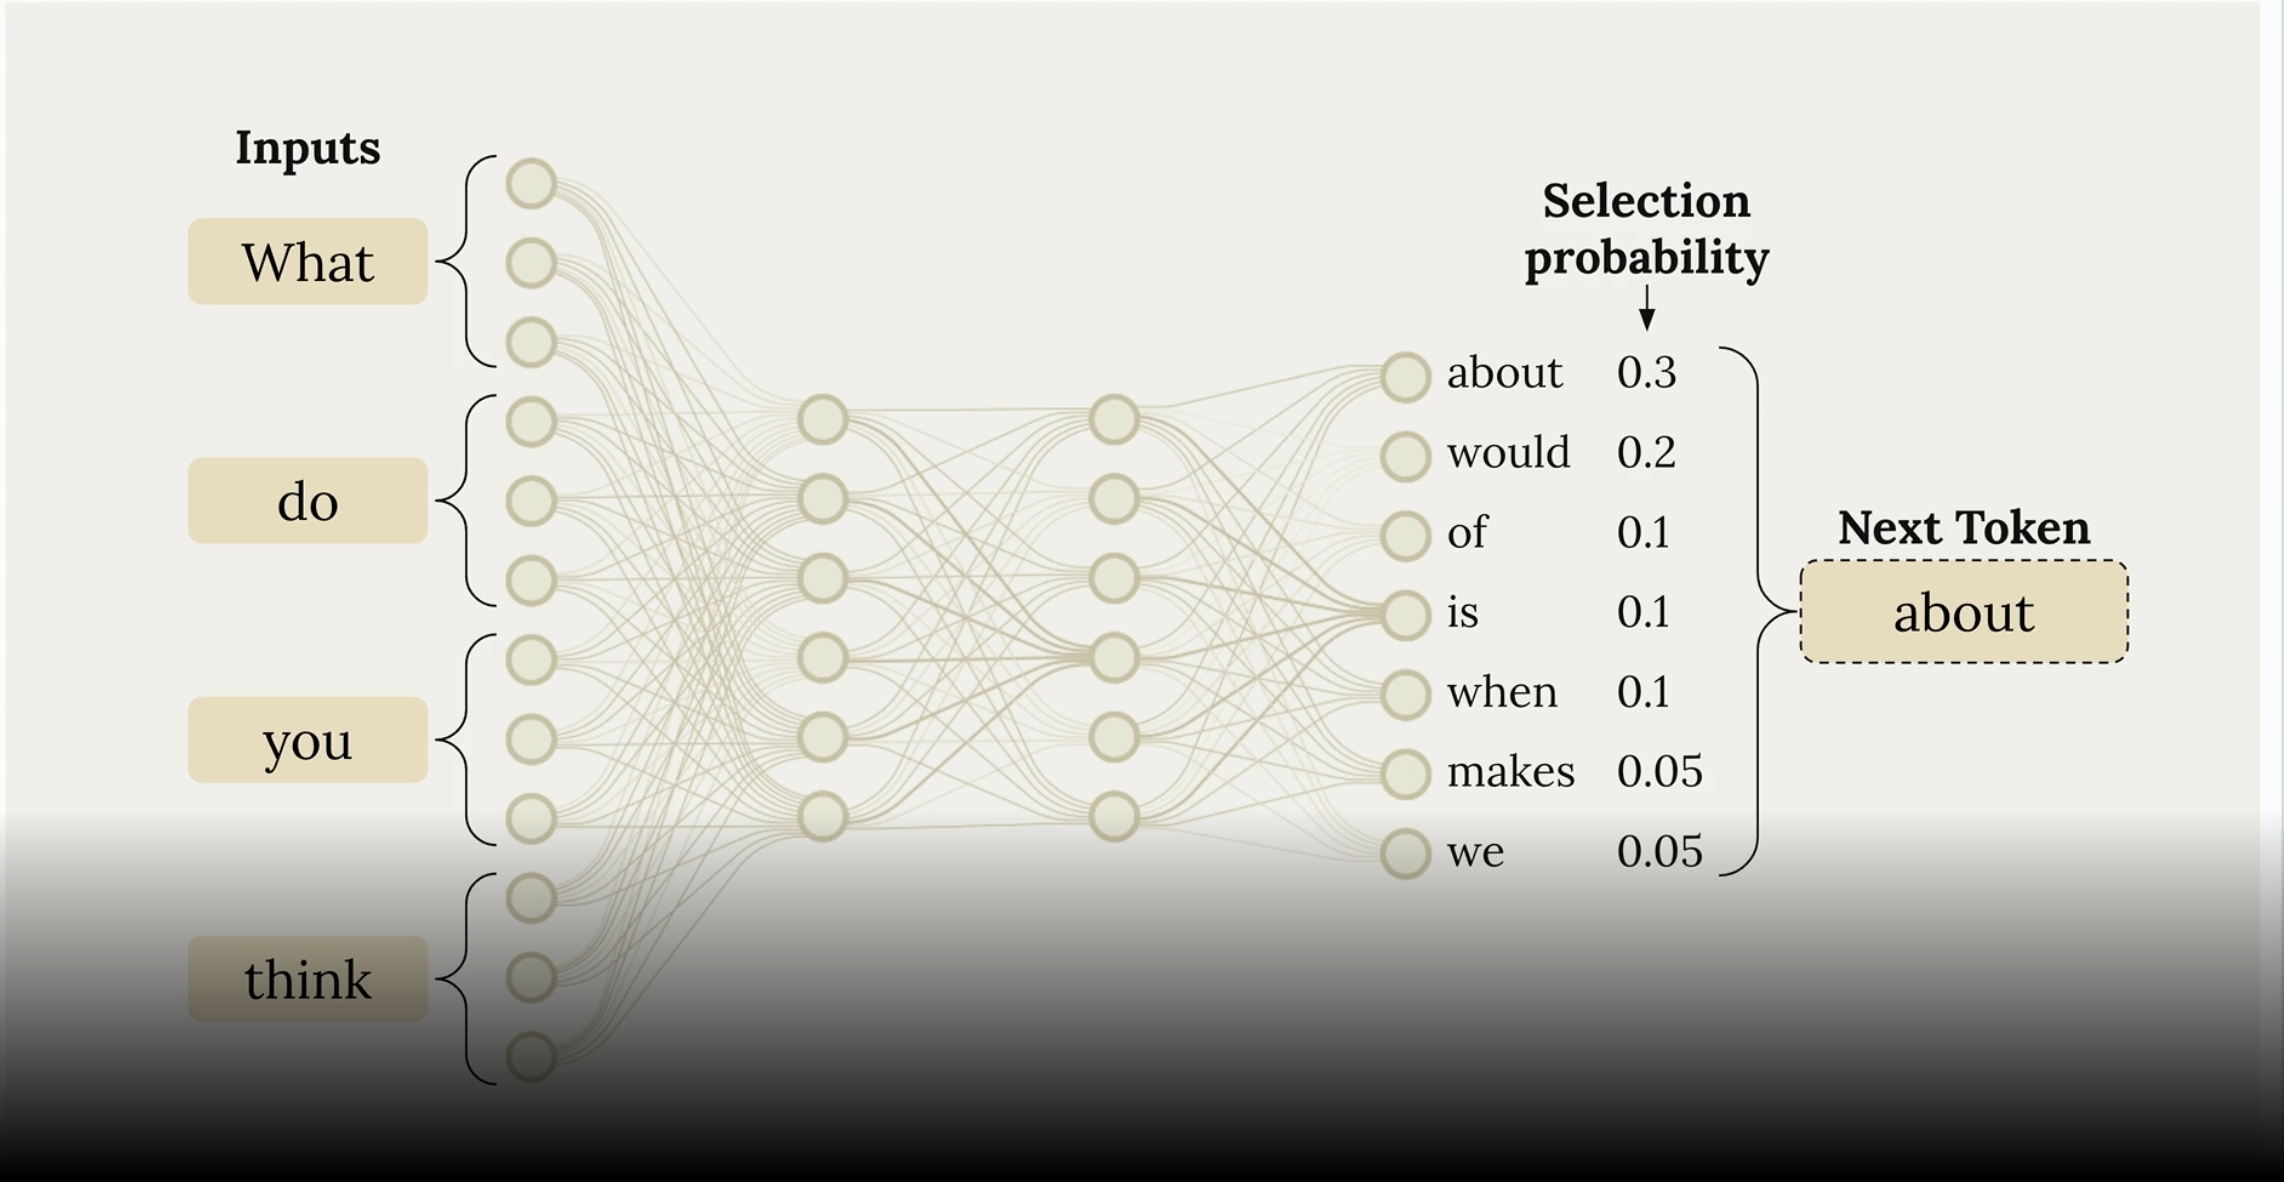

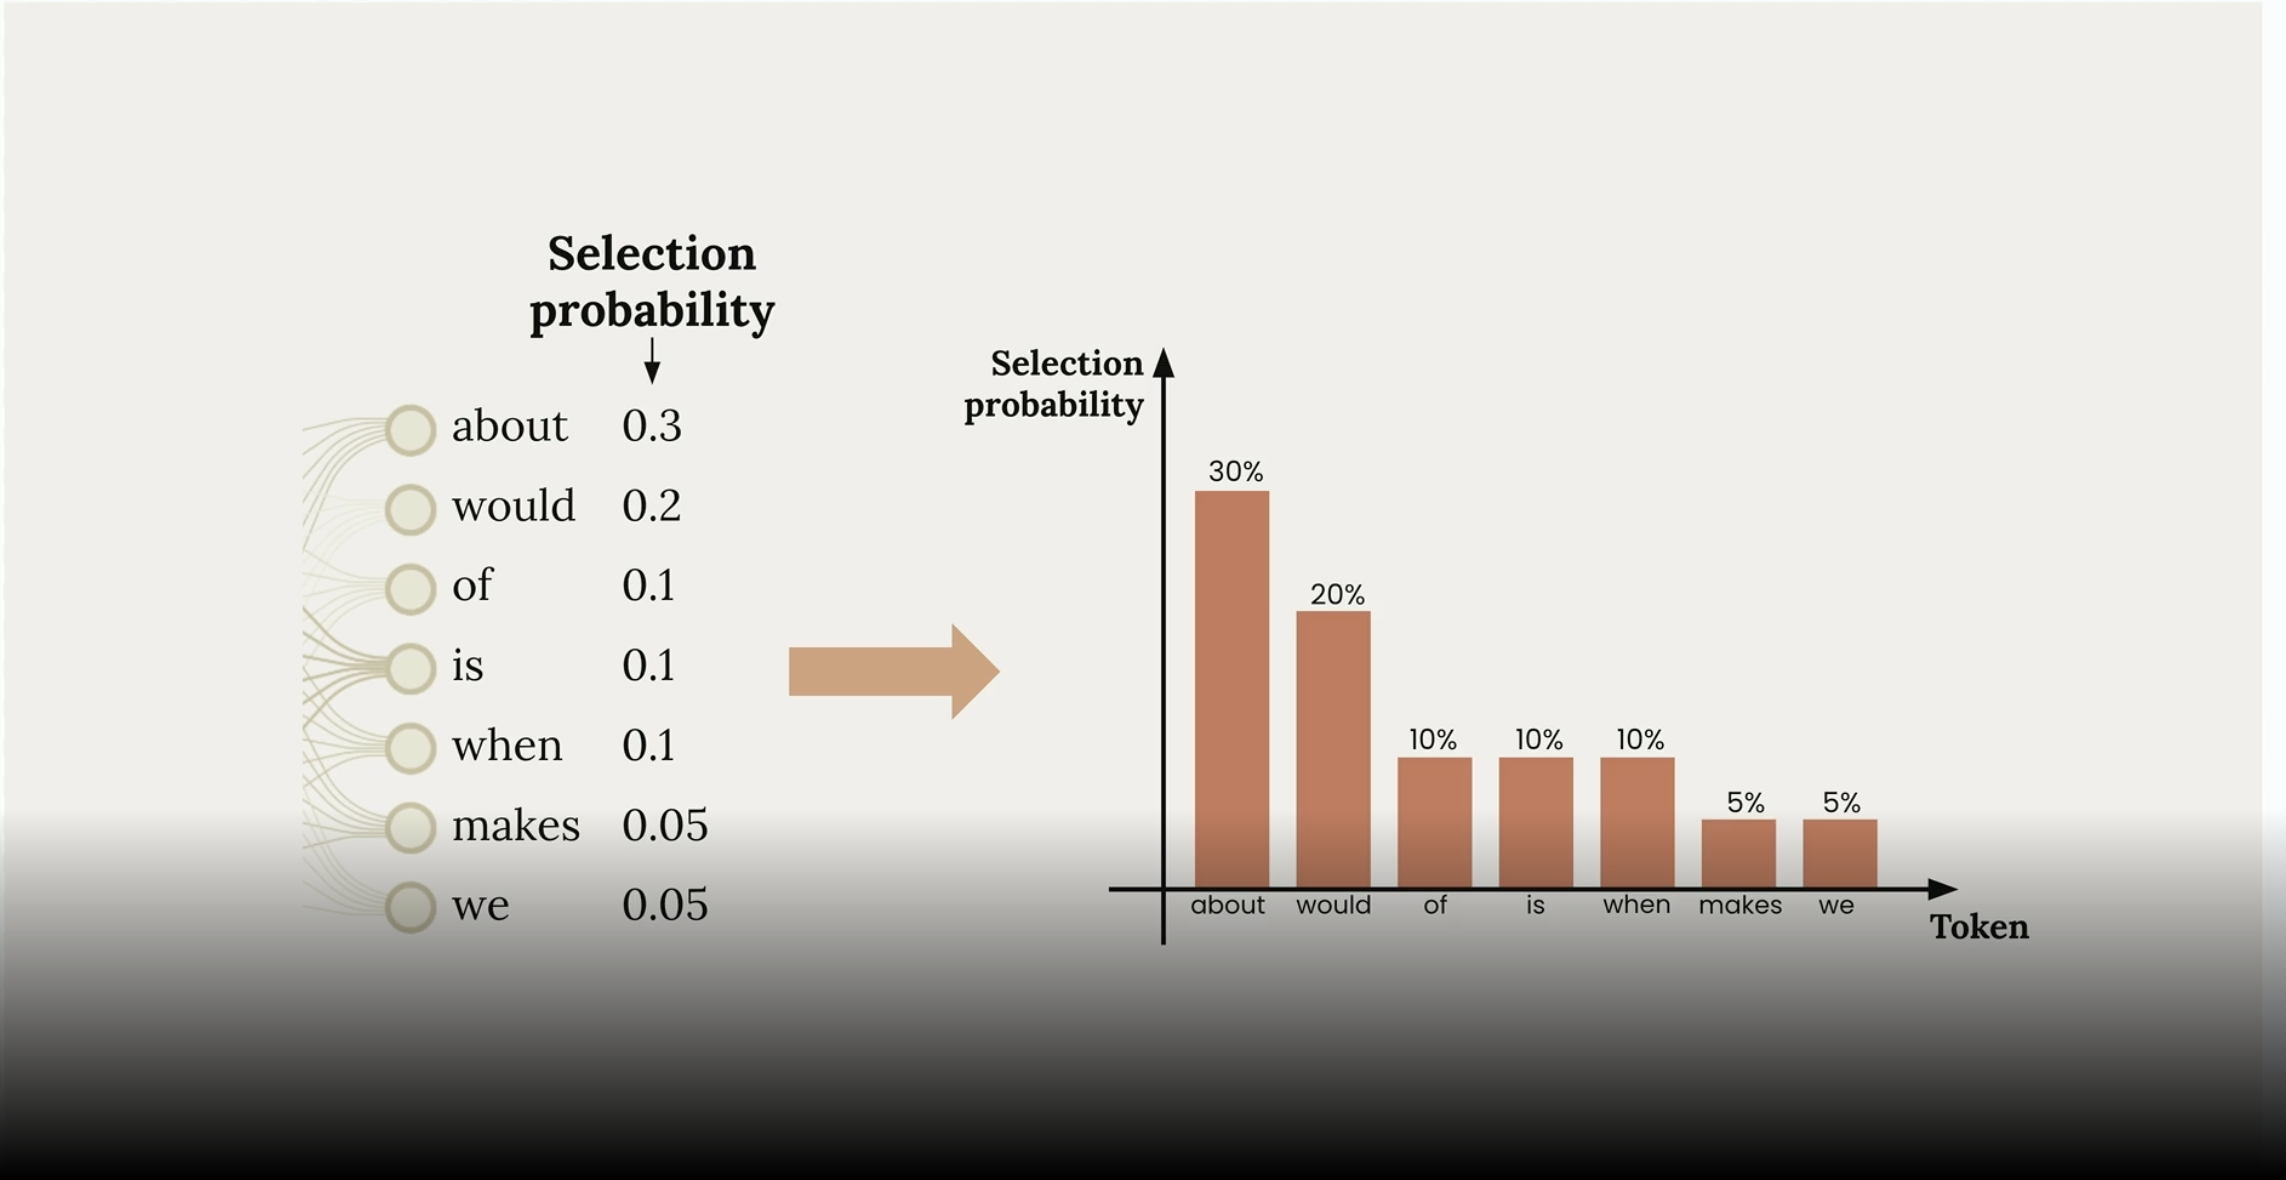

Temperature  is a probability  which controll the probability of the output. If the probability is low then the output is more deterministic  and if the temperatuer is high then the output is more random. 

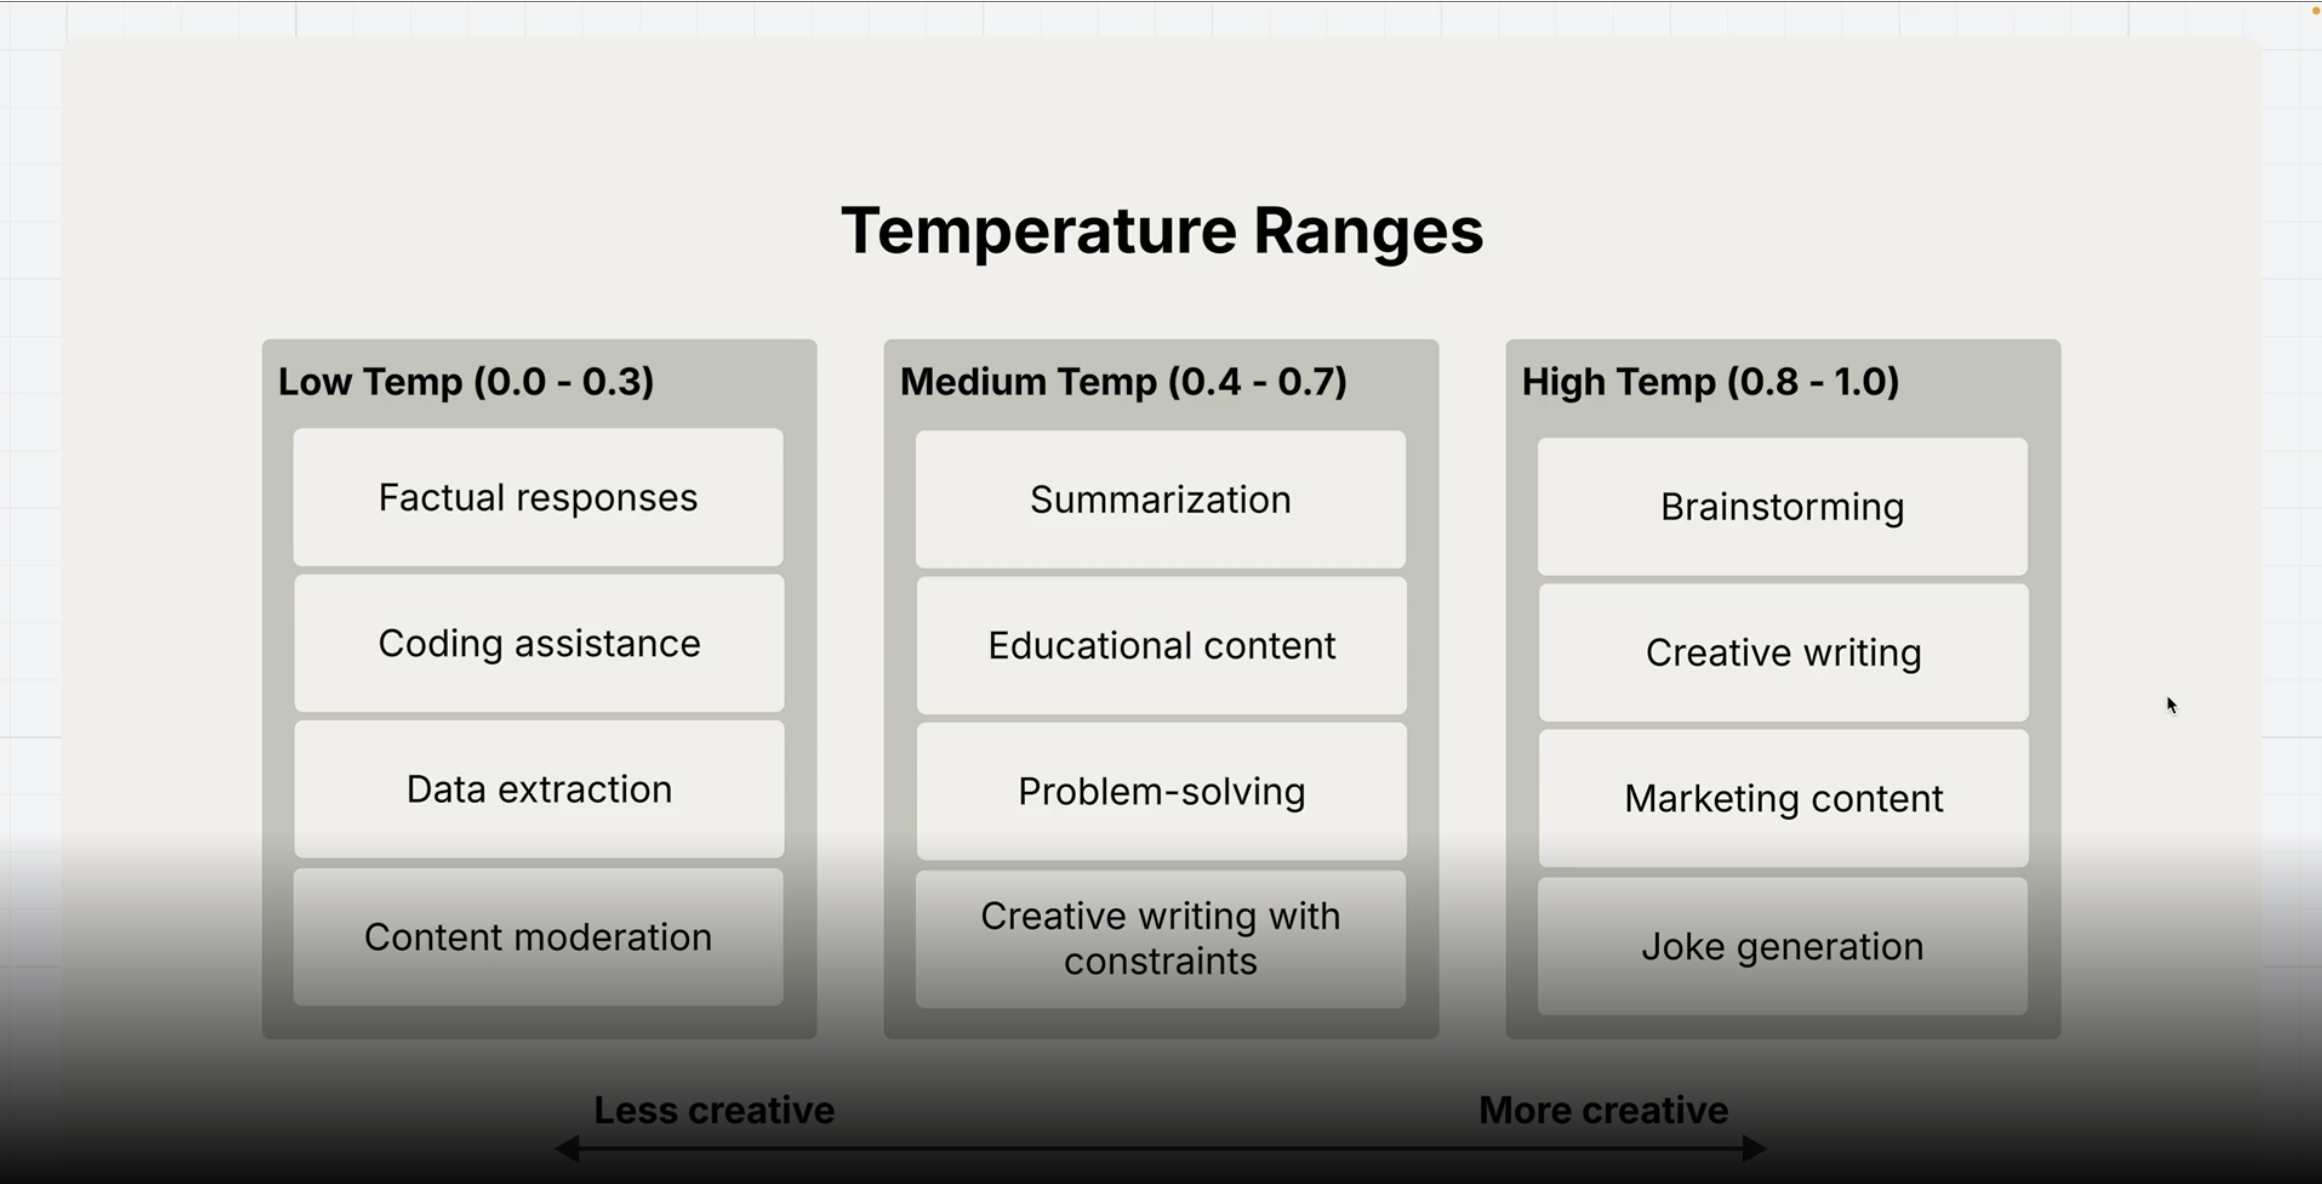

In [ ]:
messages =[]
add_user_message(messages,"Generate a one sentence movie idea")
answer = chat(messages,temperature=1)
answer

### Response Streaming ✅: 
To get the response fast through we are using response streaming. It is faster then a rest api. 

### Basic Streaming Implementation


In [ ]:
from httpx import stream
messages =[]
add_user_message(messages,"Write a 1 sentence description of a fake database")
stream = client.messages.create(model=model,max_tokens=1000,messages=messages,stream=True)
for event in stream: 
    print(event)


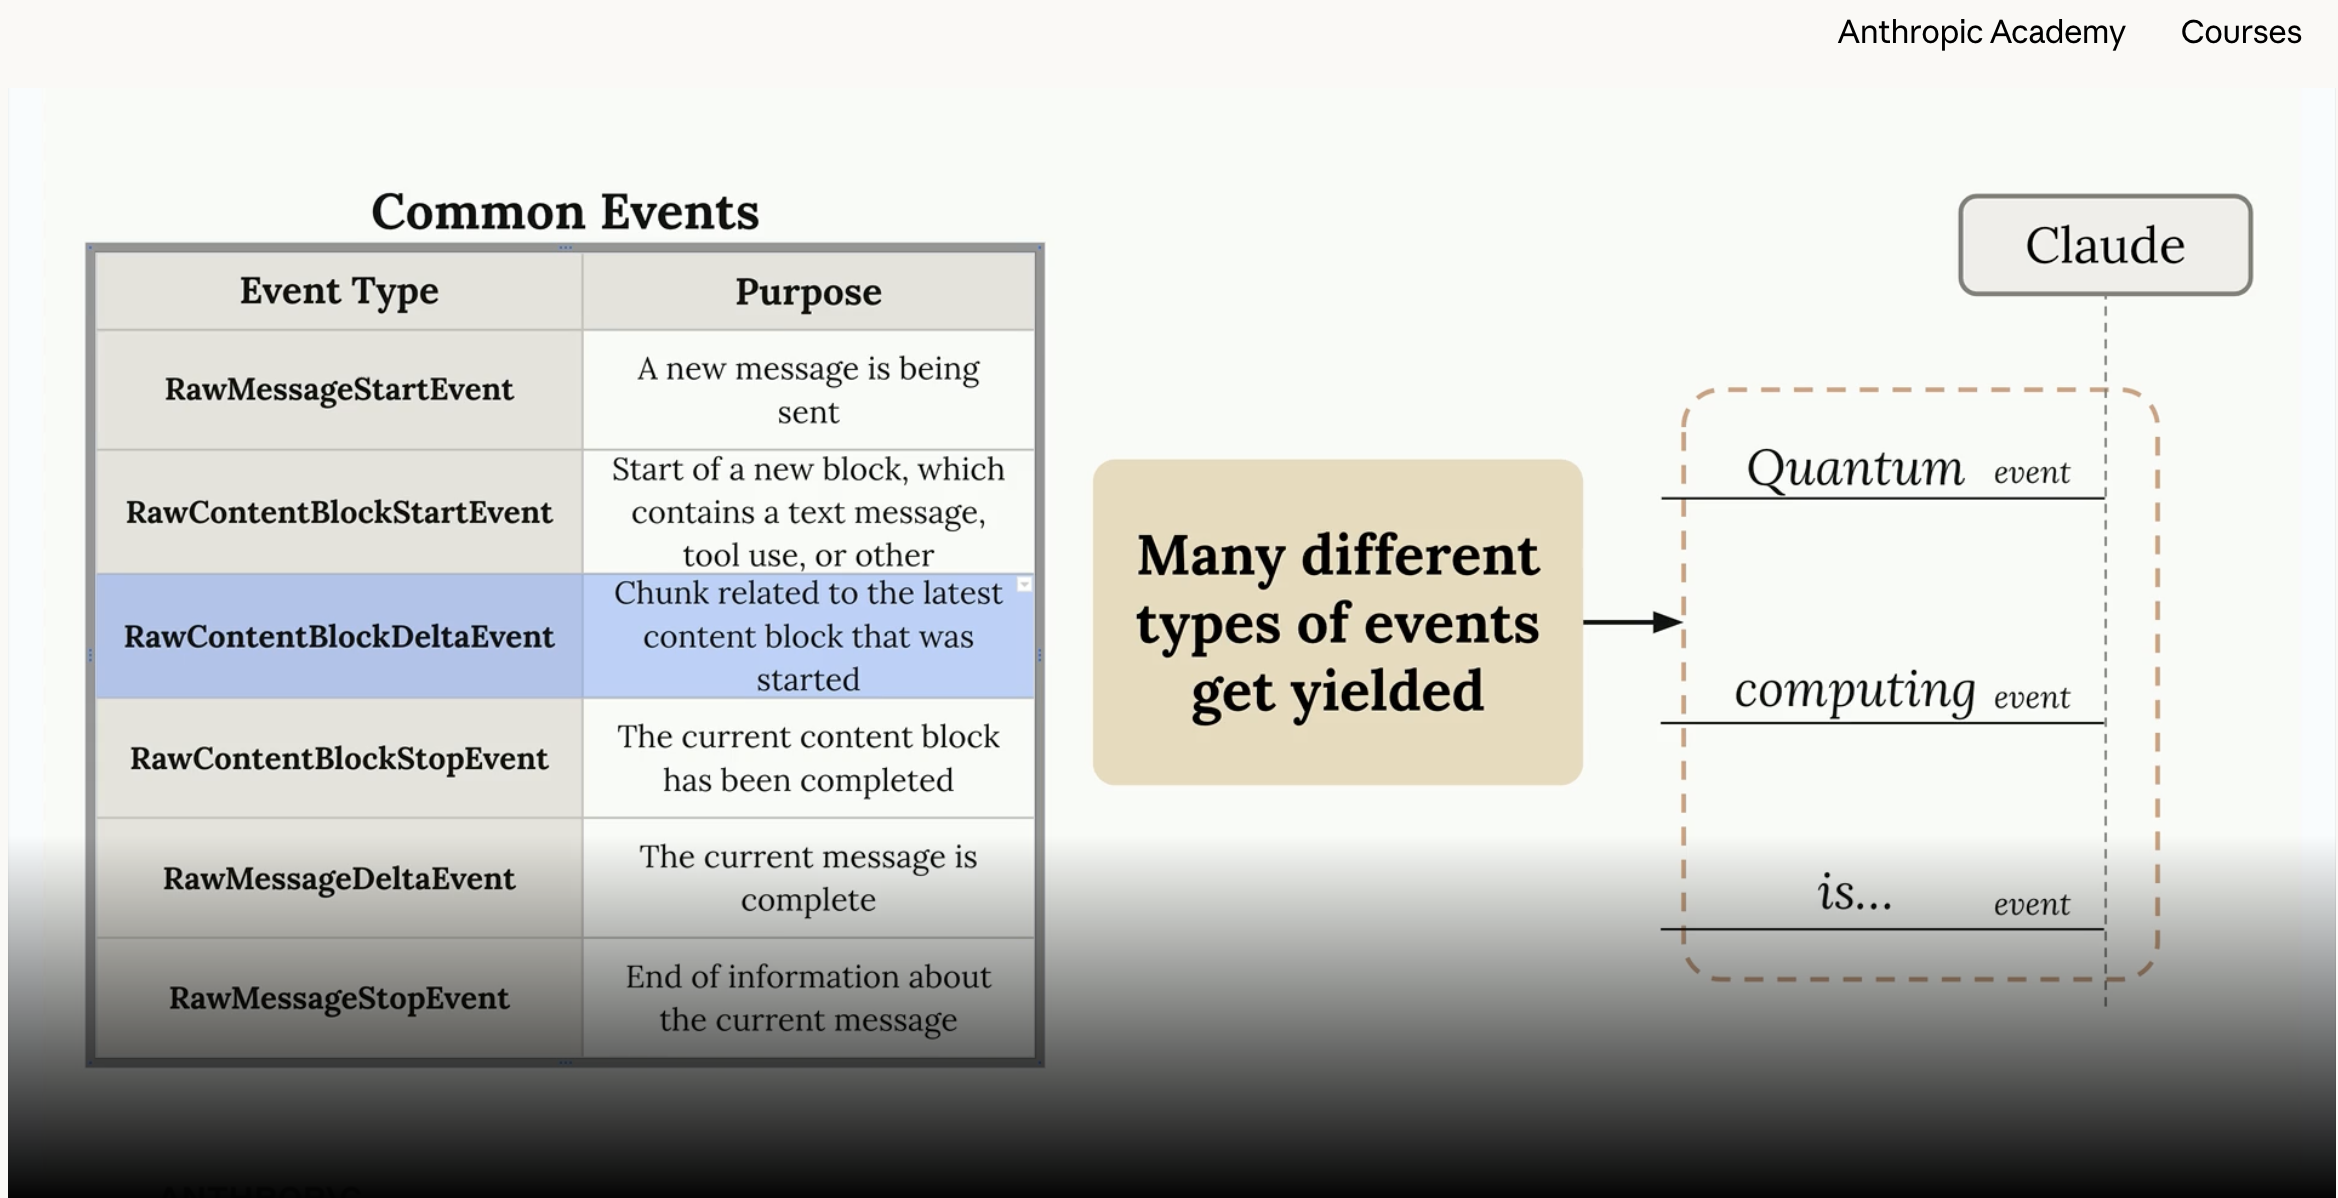

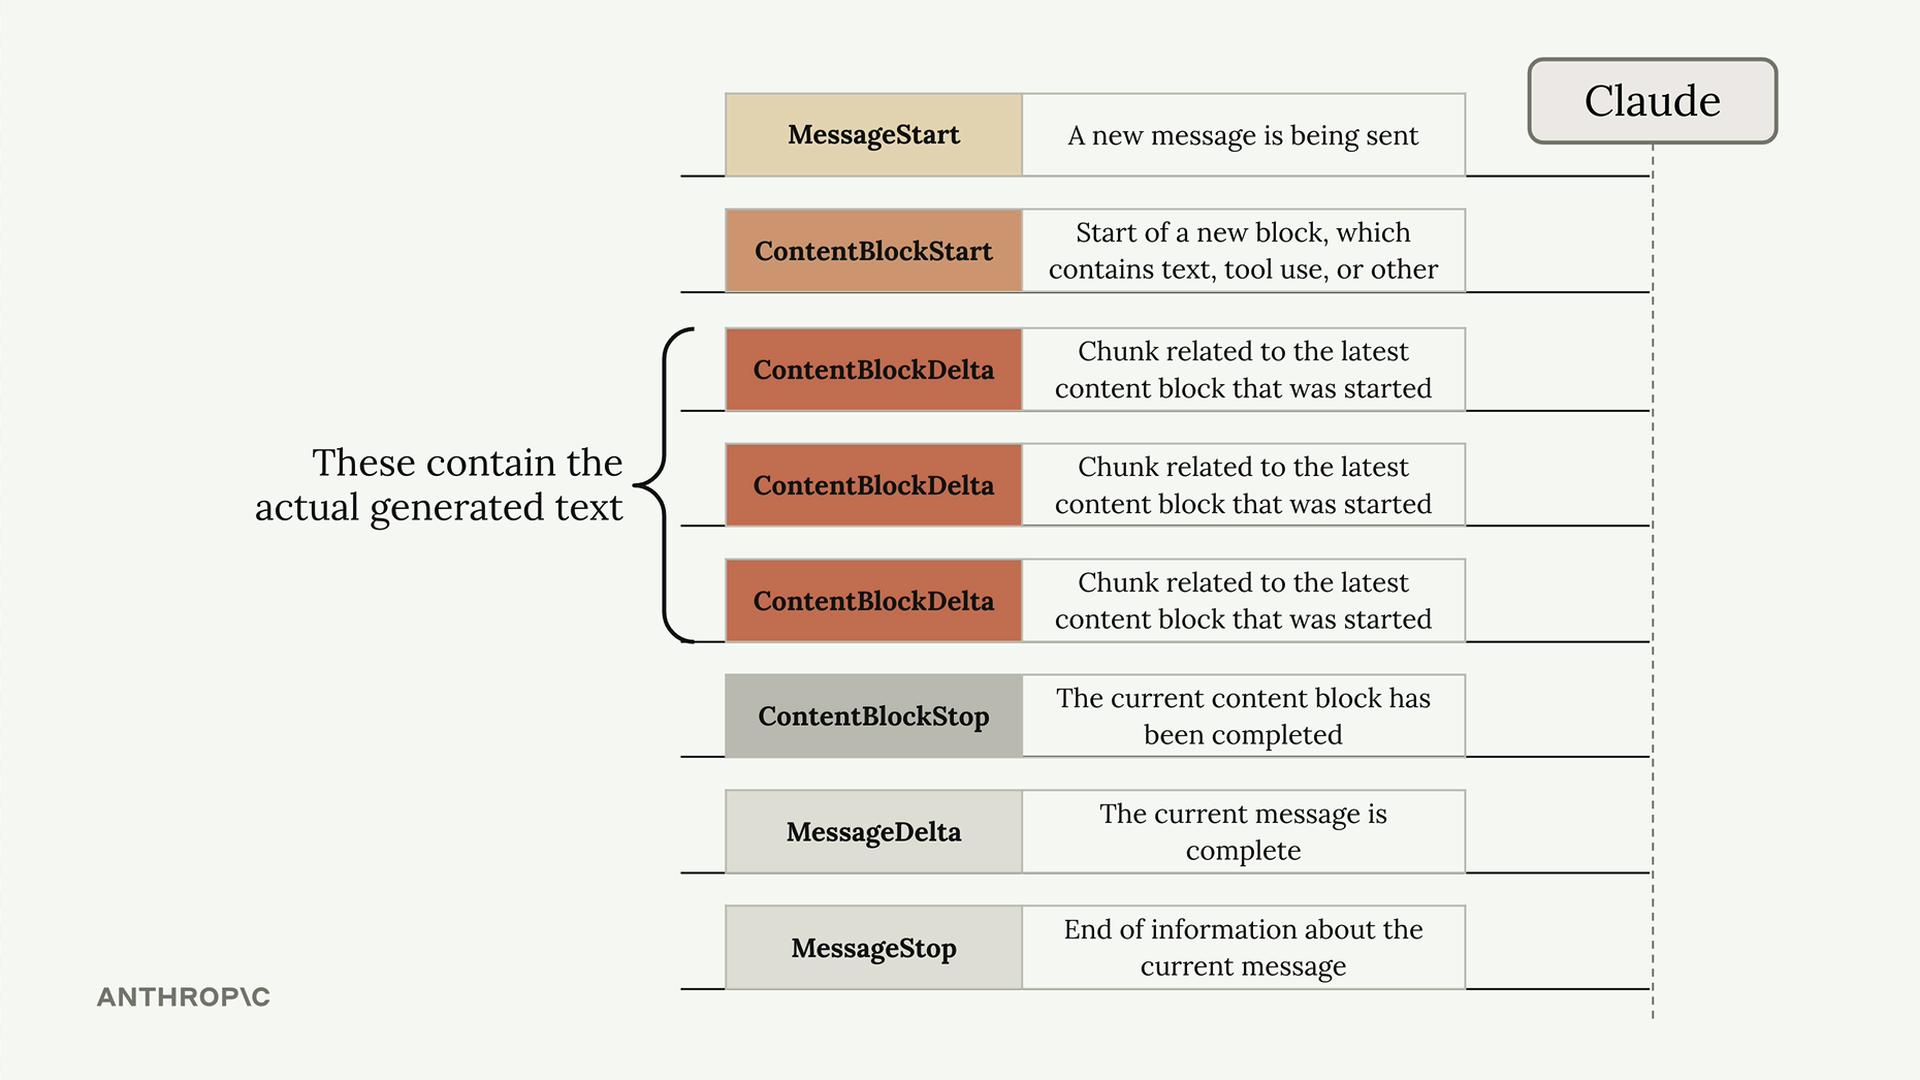

The  `ContentBlockDelta`  events contain the actual generated text that you'll want to display to users.

#### Simplified Text Streaming
Rather than manually parsing events, you can use the SDK's simplified streaming interface that extracts just the text content:



In [ ]:
messages =[]
add_user_message(messages,"Write a 1 sentence description of a fake database")

with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages=messages
) as stream:
    for text in stream.text_stream:
        print(text, end="")

This approach automatically filters out everything except the actual text content, which is usually what you need for displaying responses to users

#### Getting the Complete Message


While streaming individual chunks is great for user experience, you often need the complete message for storage or further processing. After streaming completes, you can get the assembled final message:


In [ ]:
messages =[]
add_user_message(messages,"Write a 1 sentence description of a fake database")

with client.messages.stream(
    model=model,
    max_tokens=1000,
    messages=messages
) as stream:
    for text in stream.text_stream:
        # Send each chunk to your client
        pass
    
    # Get the complete message for database storage
    final_message = stream.get_final_message()

    print(final_message)

ParsedMessage(id='msg_01MRFEeQnSE4jABG26tfCw61', container=None, content=[ParsedTextBlock(citations=None, text='Here is a one sentence description of a fake database:\n\n**"NutriTrack Pro Database"** — A fictional nutritional database containing detailed dietary information for over 500,000 food items, including made-up exotic superfoods, fictional fast-food chains, and imaginary regional cuisines from around the world.', type='text', parsed_output=None)], model='claude-sonnet-4-6', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=18, output_tokens=72, output_tokens_details=None, server_tool_use=None, service_tier='standard'))


#### Strcutured data



In [37]:
messages  = []
add_user_message(messages,"Generte a very short event bridge rule as json")
add_assistant_message(messages, "```json")
text = chat(messages, stop_sequences=["```"])

import json
clean_json = json.loads(text.strip())
clean_json

{'source': ['aws.ec2'],
 'detail-type': ['EC2 Instance State-change Notification'],
 'detail': {'state': ['running']}}

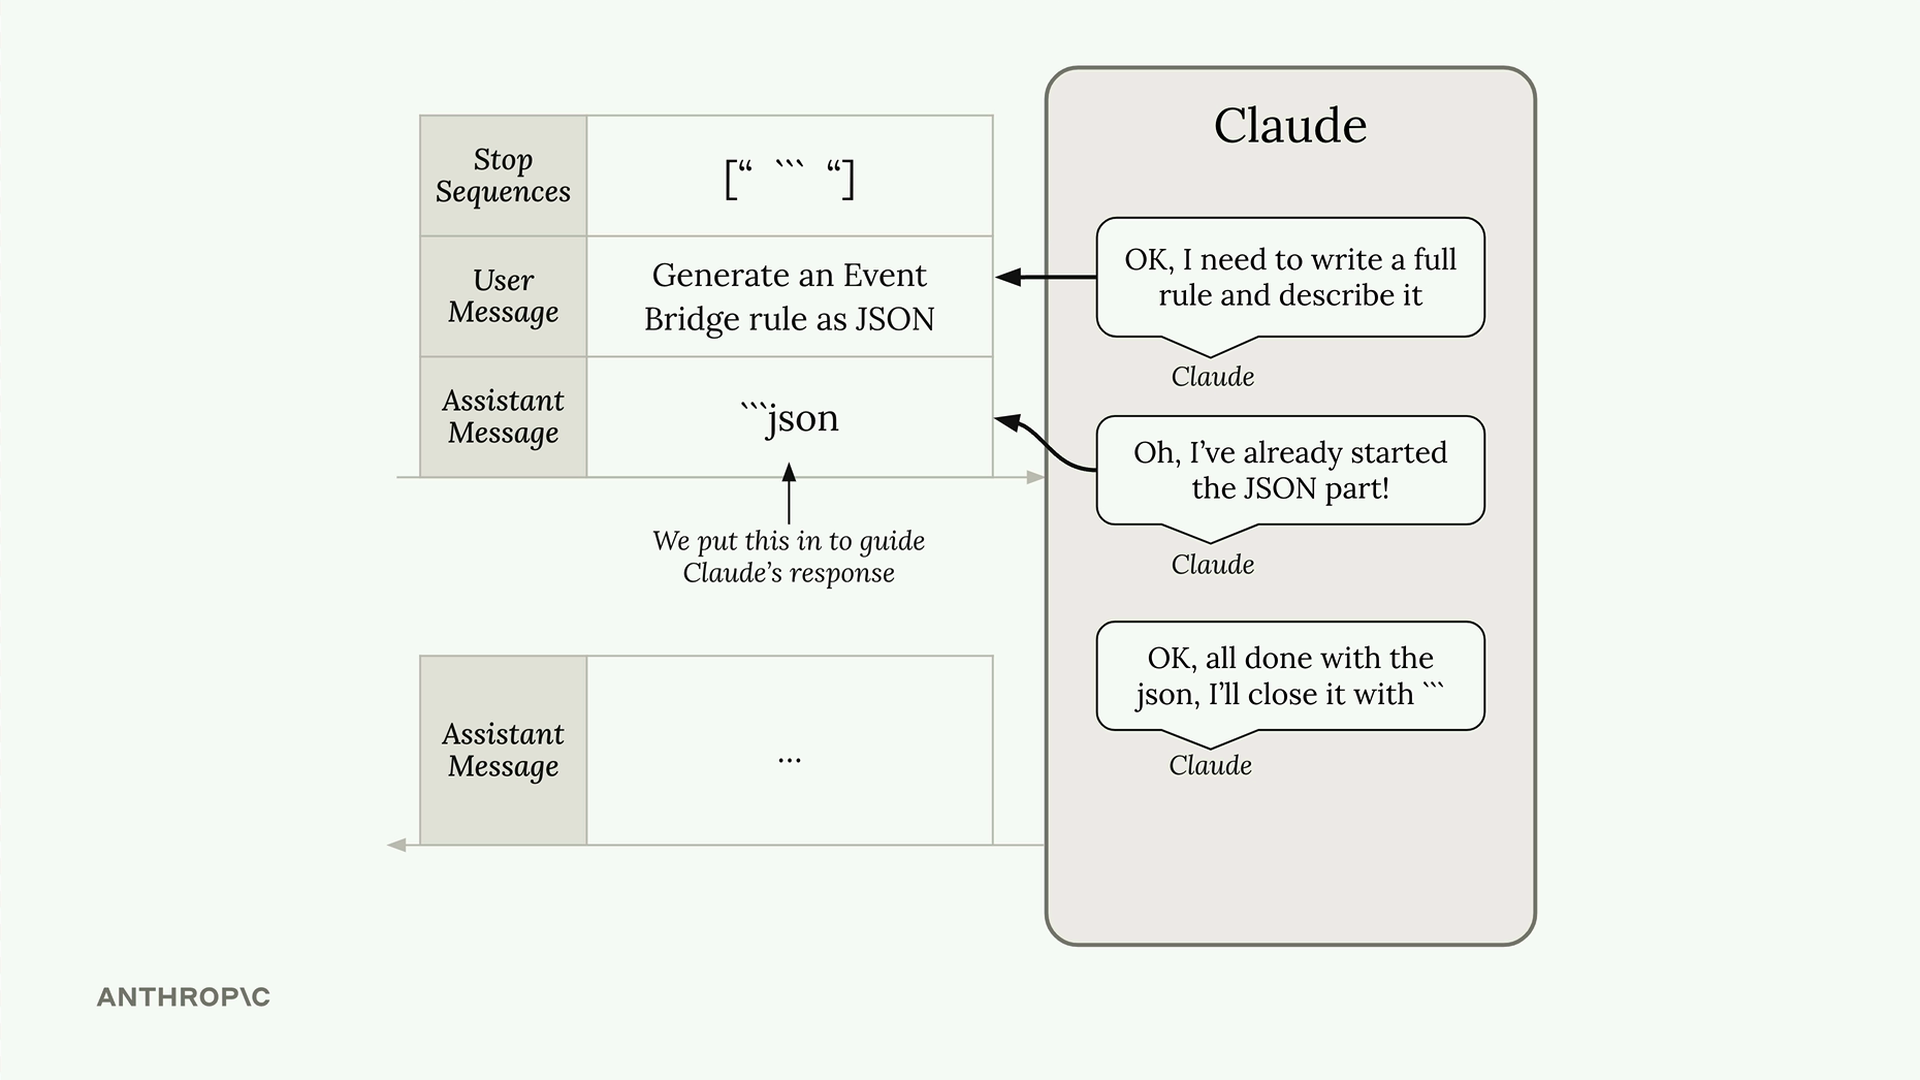

#### Beyond JSON

This technique isn't limited to JSON generation. Use it anytime you need structured data without commentary:

Python code snippets
Bulleted lists
CSV data
Any formatted content where you want just the content, not explanations
The key is identifying what Claude naturally wants to wrap your content in, then using that as your prefill and stop sequence. For code, it's usually markdown code blocks. For lists, it might be different formatting markers.

This approach gives you precise control over Claude's output format, making it much easier to integrate AI-generated content into applications where clean, structured data is essential

#### 4.Exercise 🧠

- Use message prefilling and stop sequences only to get three different commands in a single response
-  There shouldn't be any comments or explanation
-  Hint: message prefilling isn't limited to just characters like '''


In [41]:
messages =[]
prompt  = """Generate three different sample AMW CLI commands. Each should be very short"""
add_user_message(messages,prompt)
add_assistant_message(messages,"Here are all three commands in a single block without any comments:\n```bash")
text  = chat(messages,stop_sequences=["```"])
text.strip()



'amw deploy --env prod\namw logs --tail 100\namw rollback v1.2.3'